In [ ]:
#Libraries

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os

In [13]:
#Load dataset

In [3]:
df = pd.read_csv("Cleaned_Dataset.Csv")
os.makedirs("results/Cluster_Plot", exist_ok=True)

In [ ]:
#Feature Engineering 

In [4]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Revenue'] = df['Quantity'] * df['UnitPrice']
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
#RFM
rfm = df.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'Revenue': 'sum'
    })
    
rfm.rename(columns={
        'InvoiceDate': 'Recency',
        'InvoiceNo': 'Frequency',
        'Revenue': 'Monetary'
    }, inplace=True)
  
    

In [ ]:
# Behavioral features

In [5]:
rfm['Avg_Order_Value'] = rfm['Monetary'] / rfm['Frequency']
rfm['Purchase_Rate'] = rfm['Frequency'] / rfm['Recency']

In [ ]:
#Scale_features 

In [6]:
def scale_features(rfm):
    scaler = StandardScaler()
    
    #only numeric columns
    rfm_numeric = rfm.select_dtypes(include=['int64', 'float64'])
    
    scaled_data = scaler.fit_transform(rfm_numeric)
    
    rfm_scaled = pd.DataFrame(
        scaled_data,
        columns=rfm_numeric.columns,
        index=rfm.index
    )
    
    return rfm_scaled

In [ ]:
# Derived_Ratios

In [7]:
def add_derived_ratios(rfm):

    rfm = rfm.copy()

    # Avoid division by zero
    rfm['Avg_Order_Value'] = rfm['Monetary'] / (rfm['Frequency'] + 1e-6)
    rfm['Purchase_Rate'] = rfm['Frequency'] / (rfm['Recency'] + 1e-6)

    # Additional advanced ratios
    rfm['Value_per_Day'] = rfm['Monetary'] / (rfm['Recency'] + 1e-6)
    rfm['Engagement_Score'] = rfm['Frequency'] * rfm['Monetary']

    return rfm

In [ ]:
#Applying the functions

In [8]:
rfm_behavioural_features = (df)
rfm_scaled_features = scale_features(rfm_behavioural_features)
rfm = add_derived_ratios(rfm)
print("Behavioural:",rfm_behavioural_features,"\n")
print("Scaled:",rfm_scaled_features)
print(rfm.head())

Behavioural:        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   
541909    581587      POST                              POSTAGE         1   

               InvoiceDate  UnitPrice  CustomerID         Coun

In [ ]:
#Advanced Features

In [ ]:
# 1. Customer_Lifetime_Value_Segmentation

In [9]:
def customer_lifetime_value_segmentation(rfm):

    rfm = rfm.copy()

    # Simple CLV formula
    rfm['CLV'] = rfm['Monetary'] * rfm['Frequency']

    # Create segments based on CLV
    rfm['CLV_Segment'] = pd.qcut(
        rfm['CLV'],
        q=4,
        labels=['Low Value', 'Medium Value', 'High Value', 'Premium']
    )

    return rfm

In [ ]:
#Implementation

In [10]:
rfm = customer_lifetime_value_segmentation(rfm)

print(rfm[['CLV', 'CLV_Segment']].head())

                 CLV CLV_Segment
CustomerID                      
12346.0         0.00   Low Value
12347.0     30170.00     Premium
12348.0      7188.96  High Value
12349.0      1757.55  High Value
12350.0       334.40   Low Value


In [11]:
#2.Time_Based_Segmentation

In [12]:
def time_based_segmentation(rfm):

    rfm = rfm.copy()

    rfm['Customer_Type'] = pd.cut(
        rfm['Recency'],
        bins=[-1, 30, 90, 180, 3650],
        labels=['Active', 'Warm', 'Cold', 'Lost']
    )

    return rfm

In [ ]:
#Implementation

In [13]:
rfm = time_based_segmentation(rfm)

print(rfm[['Recency', 'Customer_Type']].head())

            Recency Customer_Type
CustomerID                       
12346.0         326          Lost
12347.0           2        Active
12348.0          75          Warm
12349.0          19        Active
12350.0         310          Lost


In [ ]:
#CLV Visualization

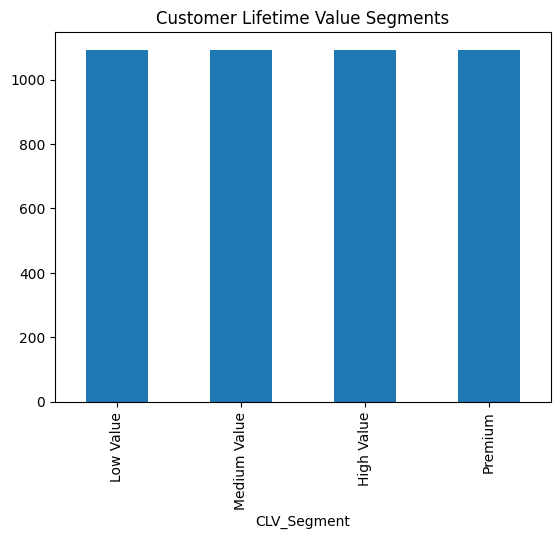

In [14]:
rfm['CLV_Segment'].value_counts().plot(kind='bar')
plt.title("Customer Lifetime Value Segments")
plt.savefig("Results/Cluster_plot/clv_segments.png")
plt.show()

In [ ]:
#Converting to CSV files to save other datasets

In [15]:
rfm.to_csv("rfm.csv",index=False)
rfm_scaled_features.to_csv("rfm_scaled.csv",index=False)